In [84]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

Data Gabungan 2023-2024

In [85]:
data = pd.read_excel('Data for Analysis.xlsx')

In [86]:
# Delete rows that contains NaN
data = data.dropna()
data.head()

,KAB_KOTA,U0,U5,U10,U15,U20,U25,U30,U35,U40,...,Total Wisata,Persentase Laki0laki,Persentase Perempuan,Jumlah Laki0laki,Jumlah Perempuan,Total Penduduk,Persebaran Lahan Sangat Kritis,Persebaran Lahan Kritis,Pengeluaran per Kapita Laki0laki,Pengeluaran per Kapita Perempuan
0,BALANGAN,9721,12636,11923,12173,10990,11445,11486,10560,9462,...,39,50.63,49.37,0,66053,133789,23659.64,15991.33,16692,11501
1,BANJAR,37569,47083,45516,48600,42859,46289,45541,48243,44602,...,23,50.47,49.53,287861,282486,570347,72044.51,33325.85,19580,11784
2,BARITO KUALA,21174,28330,28171,29144,23976,25400,25112,27036,25572,...,15,50.66,49.34,161957,157751,319708,0.00,139.53,15512,8496
3,HULU SUNGAI SELATAN,14998,19948,19556,20298,18560,18865,18164,18169,17381,...,15,50.24,49.76,0,116892,234909,23829.13,8680.25,20057,9255
4,HULU SUNGAI TENGAH,16658,21814,21834,23182,20625,20577,19629,19057,19297,...,11,50.29,49.71,0,131739,265009,24668.85,6390.33,14139,12388


In [87]:
# Define the data
X = data.iloc[:,1:].values
X

array([[ 9721.  , 12636.  , 11923.  , ..., 15991.33, 16692.  , 11501.  ],
       [37569.  , 47083.  , 45516.  , ..., 33325.85, 19580.  , 11784.  ],
       [21174.  , 28330.  , 28171.  , ...,   139.53, 15512.  ,  8496.  ],
       ...,
       [28082.  , 34830.  , 31118.  , ..., 39670.37, 20009.  ,  7600.  ],
       [25553.  , 31680.  , 31285.  , ..., 33010.53, 18312.  ,  8458.  ],
       [13373.  , 17791.  , 16350.  , ...,  6542.42, 19250.  ,  7001.  ]])

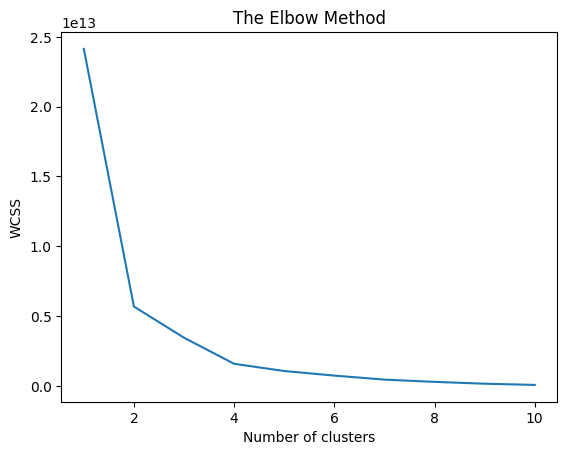

In [88]:
# Using the elbow method to find the optimal number of clusters
wcss =[]
for i in range (1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter =300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the graph to visualize the Elbow Method to find the optimal number of cluster
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

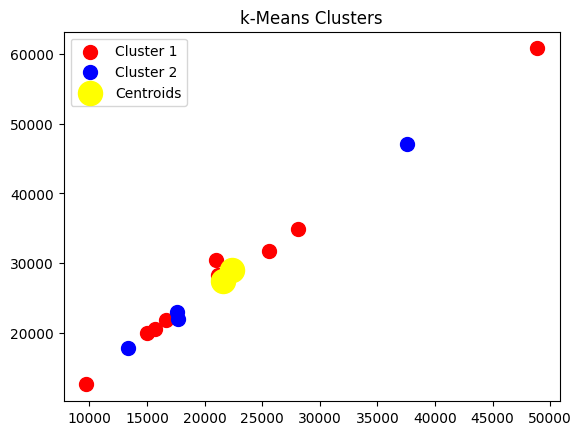

In [89]:
# K-Means Clustering
kmeans=KMeans(n_clusters= 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
Y_Kmeans = kmeans.fit_predict(X)

# Visualising the clusters
plt.scatter(X[Y_Kmeans == 0, 0], X[Y_Kmeans == 0,1],s = 100, c='red', label = 'Cluster 1')
plt.scatter(X[Y_Kmeans == 1, 0], X[Y_Kmeans == 1,1],s = 100, c='blue', label = 'Cluster 2')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('k-Means Clusters')
plt.legend()
plt.show()

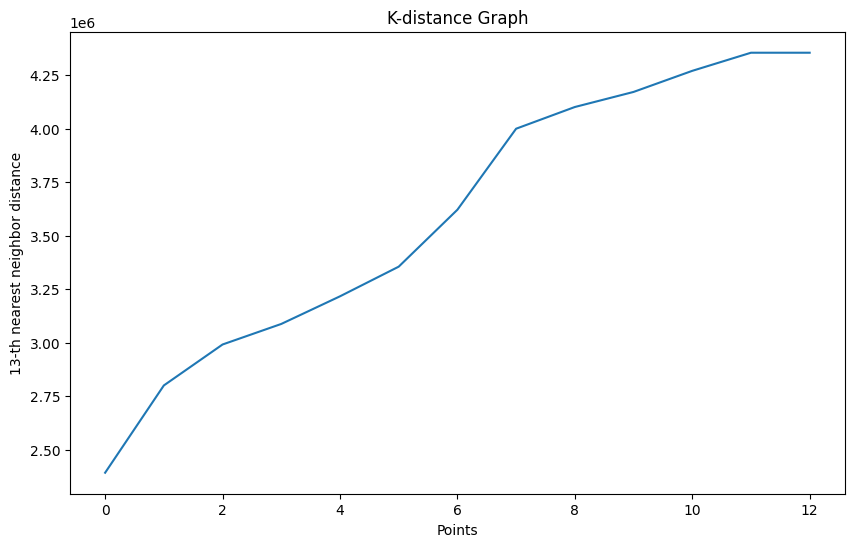

In [90]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=13)

In [91]:
# Perform DBSCAN clustering
# Find optimal min_samples using Silhouette analysis
best_min_samples = 2  # Initialize
best_silhouette_score = -1

for min_samples in range(2, 101): # Test a range of min_samples
  dbscan = DBSCAN(eps=4, min_samples=min_samples) # Use the epsilon determined previously
  clusters = dbscan.fit_predict(X)

  # Check if the clustering resulted in more than one cluster and no all points are noise
  if len(set(clusters)) > 1 and -1 not in clusters or list(clusters).count(-1) < len(clusters):
    silhouette_avg = silhouette_score(X, clusters)
    if silhouette_avg > best_silhouette_score:
      best_silhouette_score = silhouette_avg
      best_min_samples = min_samples

print(f"Optimal min_samples based on Silhouette Score: {best_min_samples}")

# Perform DBSCAN clustering with the optimal min_samples
dbscan = DBSCAN(eps=4, min_samples=best_min_samples)
clusters = dbscan.fit_predict(X)

Optimal min_samples based on Silhouette Score: 2


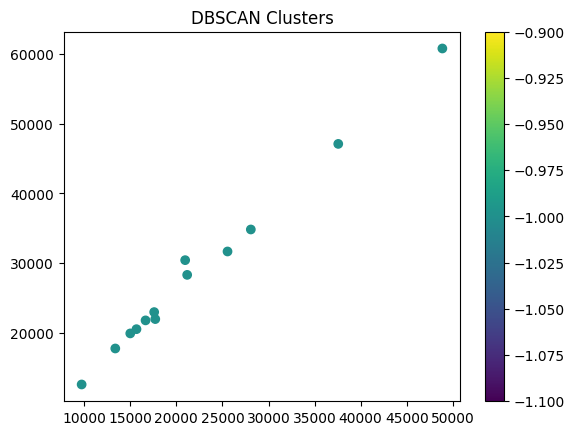

In [92]:
# Visualize the results
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clusters')
plt.show()

In [93]:
# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters+1}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 1
Number of noise points: 13


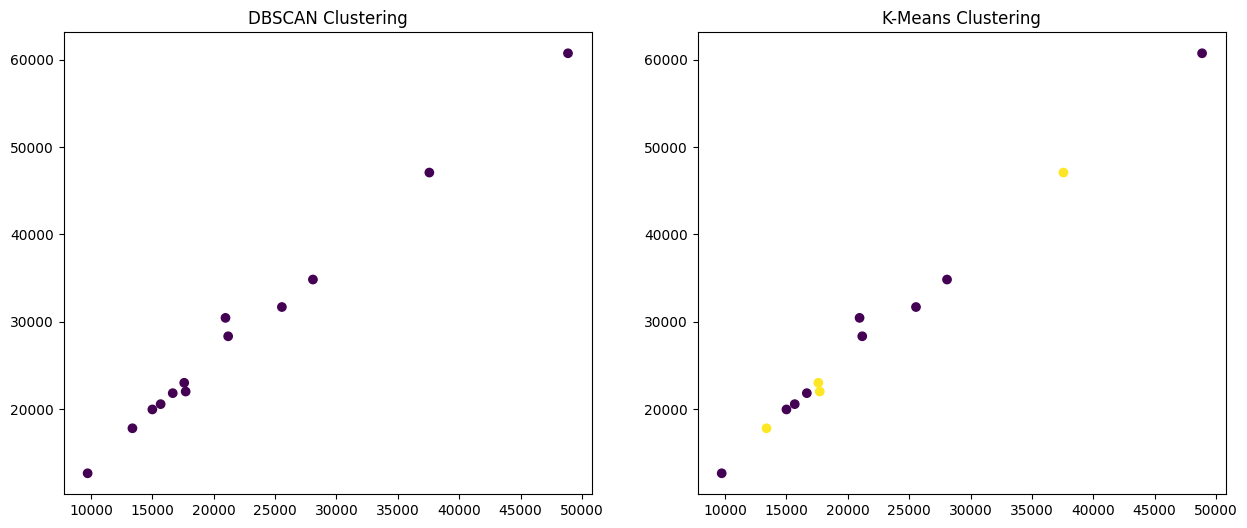

In [94]:
# DBSCAN clustering
dbscan = DBSCAN(eps=4, min_samples=2)
dbscan_labels = dbscan.fit_predict(X)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
ax1.set_title('DBSCAN Clustering')
ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax2.set_title('K-Means Clustering')
plt.show()

In [95]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for K-Means
silhouette_kmeans = silhouette_score(X, kmeans_labels)
print(f"Silhouette Score for K-Means: {silhouette_kmeans}")

# Calculate Silhouette Score for DBSCAN
silhouette_dbscan = best_silhouette_score
print(f"Silhouette Score for DBSCAN: {silhouette_dbscan}")

# Compare the scores
if silhouette_kmeans > silhouette_dbscan:
    print("K-Means is the better clustering method based on Silhouette Score.")
elif silhouette_dbscan > silhouette_kmeans:
    print("DBSCAN is the better clustering method based on Silhouette Score.")
else:
    print("Both K-Means and DBSCAN have similar Silhouette Scores.")

Silhouette Score for K-Means: 0.6282551558952437
Silhouette Score for DBSCAN: -1
K-Means is the better clustering method based on Silhouette Score.


TOPSIS

In [96]:
# Calculate the mean of each feature for each cluster
cluster_means = []
for i in range(len(kmeans.cluster_centers_)):
    cluster_data = X[kmeans_labels == i]
    cluster_means.append(np.mean(cluster_data, axis=0))

criteria_weight = np.array(cluster_means)

# Criteria preference can be set based on domain knowledge or cluster characteristics
criteria_preference = np.ones(X.shape[1])

In [97]:
criteria_matrix = X

In [98]:
criteria_matrix = np.array(criteria_matrix, dtype=np.float64)
column_sums = (criteria_matrix ** 2).sum(axis=0)
with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for division by zero
    norm_matrix = criteria_matrix / np.sqrt(column_sums)
    norm_matrix = np.nan_to_num(norm_matrix) #Handle NaN values resulting from division by zero

In [99]:
def weighted_matrix(criteria_weight, normalized_matrix):
    normalized_rows = len(normalized_matrix)
    normalized_columns = len(normalized_matrix[0])

    weighted_matrix = []
    for i in range(normalized_rows):
        weighted_matrix_rows = []
        for j in range(normalized_columns):
            weighted_matrix_rows.append(normalized_matrix [i][j]* criteria_weight[j])
        weighted_matrix.append(weighted_matrix_rows)

    print('\nWeighted matrix from normalized matrix: ')
    for i in weighted_matrix:
        for j in i:
            print(f'{j:.4f}',end=' ')
        print()
    return weighted_matrix

In [100]:
weighted_matrix_1 = weighted_matrix(criteria_weight[0].flatten(),norm_matrix)
weighted_matrix_2 = weighted_matrix(criteria_weight[1].flatten(),norm_matrix)


Weighted matrix from normalized matrix: 
2470.8112 3259.3235 3098.7733 3150.0872 2820.6714 2914.5675 2912.1753 2645.9830 2368.7404 2148.6064 1847.9510 1487.1546 943.1668 555.9462 331.9175 337.6779 7281.2191 3004.5734 12830.5228 4761.6647 3840.8059 162.9498 181.4455 869.2920 30.9313 0.1123 0.0962 2.2155 0.1225 0.1853 53.2096 42.0880 0.1824 0.9940 10.3668 0.6730 0.7065 3.0442 5.5370 0.3182 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 3.6703 4.6910 0.0000 0.0000 0.0000 0.0000 3680.7191 3084.7029 0.0000 0.0000 21627.2296 0.0000 0.0000 372

In [101]:
def ideal_best_worst(weighted_matrix,criteria_preferences):
    weighted_column = len(weighted_matrix[0])
    positive_ideal= []
    negative_ideal = []

    for j in range(weighted_column):
        max_value = weighted_matrix[0][j]
        min_value = weighted_matrix[0][j]

        for i in range(len(weighted_matrix)):
            if weighted_matrix[i][j] > max_value:
                max_value = weighted_matrix [i][j]
            if weighted_matrix[i][j] < min_value:
                min_value = weighted_matrix [i][j]
        if criteria_preferences[j] == 1:
            positive_ideal.append(max_value)
            negative_ideal.append(min_value)
        else:
            positive_ideal.append(min_value)
            negative_ideal.append(max_value)

    print('\nPositive ideal point for each column: ')
    for i in positive_ideal:
        print(f'{i:.4f}',end=' ')
    print()
    print('\nNegative ideal point for each column: ')
    for i in negative_ideal:
        print(f'{i:.4f}',end=' ')
    print()

    return positive_ideal, negative_ideal

In [102]:
ideal_1 = ideal_best_worst(weighted_matrix_1,criteria_preference)
ideal_2 = ideal_best_worst(weighted_matrix_2,criteria_preference)


Positive ideal point for each column: 
12420.6491 15668.7927 15484.7698 14788.3047 13293.3443 13383.3274 13154.4830 13848.3132 13167.2628 12179.5460 10176.5844 8084.5400 5914.7958 3831.5209 2280.0732 2378.3722 40507.0406 20022.0707 43238.0528 25041.9856 36576.2236 1133.5642 2453.8622 8705.7349 625.4122 28.1880 0.2887 6.8927 13.4705 0.5560 126.6767 82.2874 1.6414 12.3261 33.2268 36.1153 4.7098 9.6860 16.3474 3.3408 1.7175 3.2069 0.2963 0.5186 0.8394 0.0000 1.4926 2.4739 6.0754 1.1667 1.1358 202.7476 0.3727 5.7205 6.2804 6.2995 4.9416 1.7452 0.8269 0.0000 2.8996 0.4939 2.4394 0.0000 1.4327 1.9698 0.4321 0.0642 0.1571 0.1111 1.4950 5.6623 0.5238 0.0000 1.2172 0.0786 0.3563 0.1988 9.7771 1.6667 6.8889 1.0000 0.1571 0.1111 1.2222 1.0000 5.4395 3.4444 0.5556 0.5556 0.1111 0.1571 0.8889 6.5462 0.1111 0.1571 2.3333 2.6667 6.4444 1.0000 0.4312 6.8889 0.2222 0.1111 1.0000 1.6667 1.5556 1.0000 0.1111 0.1111 0.0000 0.0000 16.3632 106.0810 4.6601 315.7058 535.5394 54711.4477 33585.3547 14107.3745 

In [103]:
def separation_from_ideal_point(weighted_matrix,positive_ideal,negative_ideal):
    weighted_rows = len(weighted_matrix)
    positive_separation = []
    negative_separation = []

    for i in range(weighted_rows):
        pos_sep = 0
        neg_sep = 0
        for j in range(len(positive_ideal)):
            pos_sep += (weighted_matrix[i][j] - positive_ideal[j]) ** 2
            neg_sep += (weighted_matrix[i][j] - negative_ideal[j]) ** 2
        positive_separation.append(pos_sep ** 0.5)
        negative_separation.append(neg_sep ** 0.5)

    print('\nPositive separation: ')
    for i in (positive_separation):
        print(f'{i:.4f}')
    print('\nNegative separation: ')
    for i in (negative_separation):
        print(f'{i:.4f}')
    return positive_separation,negative_separation

In [104]:
separation_1 = separation_from_ideal_point(weighted_matrix_1,ideal_1[0],ideal_1[1])
separation_2 = separation_from_ideal_point(weighted_matrix_2,ideal_2[0],ideal_2[1])


Positive separation: 
450724.9071
162162.7424
417184.4927
411399.4718
416986.5554
436224.5451
213668.9363
282974.0718
331777.0060
159187.2346
332958.0682
363310.2117
262977.7657

Negative separation: 
22932.6530
309343.6847
75836.4447
52847.6954
50099.5556
35867.6486
289182.7368
224514.7360
151904.8921
408113.9915
136955.4544
108327.8648
223146.5970

Positive separation: 
1993887.6640
658862.9471
1901673.4768
1829421.2278
1876022.8380
1951723.8520
607270.7661
1255814.4967
1522228.7480
164654.4556
1464273.2131
1649821.7760
915761.2203

Negative separation: 
24045.1051
1340269.6939
112038.6644
167430.9354
123799.0946
53719.8903
1405341.2721
753568.1448
481742.0361
1984131.8271
534737.3815
350067.9765
1089090.0653


In [105]:
def similarities_to_PIS(positive_separation,negative_separation):
    num_rows = len(positive_separation)
    relative_similarity = []

    for i in range(num_rows):
        pos_sep = positive_separation[i]
        neg_sep = negative_separation[i]
        similarity = neg_sep/(pos_sep + neg_sep)
        relative_similarity.append(similarity)

    print('\nOrder: ')
    for i in (relative_similarity):
        print(f'{i:.4f}')
    return relative_similarity

In [106]:
similarity_1 = similarities_to_PIS(separation_1[0],separation_1[1])
similarity_2 = similarities_to_PIS(separation_2[0],separation_2[1])


Order: 
0.0484
0.6561
0.1538
0.1138
0.1073
0.0760
0.5751
0.4424
0.3141
0.7194
0.2914
0.2297
0.4590

Order: 
0.0119
0.6704
0.0556
0.0838
0.0619
0.0268
0.6983
0.3750
0.2404
0.9234
0.2675
0.1750
0.5432
